<a href="https://colab.research.google.com/github/Yusra-Zafar/Simple-ANN-with-PyTorch-for-FMNIST/blob/main/ANN_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a simple ANN with PyTorch

In [1]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
# set random seed
torch.manual_seed(42)

Using GPU in PyTorch
1. Check device availability
2. Move the model to GPU
3. Modify the training loop by moving data to GPU
4. Modify the eval loop by moving data to GPU
5. Optimize GPU usage

    a. Use larger batch sizes (64, 128)

    b. Enable DataLoader pinning (pin_memory=True)

### device agnostic code

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using '{device}' device")

Using 'cuda' device


### importing FMNIST dataset from PyTorch

In [4]:
import torchvision
import torchvision.transforms as transforms
import pandas as pd


# Define a transformation to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load the Fashion MNIST training dataset
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Extract features and labels from the full dataset
full_images = []
full_labels = []

for img, label in train_dataset_full:
    full_images.append(img.flatten().numpy())
    full_labels.append(label)

X = pd.DataFrame(full_images)
y = pd.Series(full_labels)


print(f"Loaded {len(X)} samples into X and y from Fashion MNIST.")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.6MB/s]


Loaded 60000 samples into X and y from Fashion MNIST.


### Split data into train, test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling data

In [6]:
# scale dataset
X_train = X_train/255.0
X_test = X_test/255.0

In [7]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
48572,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
38696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000477,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
13611,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
35213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000046,...,0.001984,0.001968,0.002261,0.002584,0.001984,0.000000,0.000000,0.0,0.0,0.0
31766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000046,0.000877,0.001446,...,0.000000,0.000000,0.000000,0.000000,0.001845,0.001646,0.000431,0.0,0.0,0.0


In [8]:
len(X_train)

48000

In [9]:
len(y_train)

48000

In [10]:
len(y_test)

12000

In [11]:
X_train.shape

(48000, 784)

In [12]:
type(X_train)

pandas.core.frame.DataFrame

### Convert pandas DataFrame into numpy arrays

In [13]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [14]:
type(X_test),


(numpy.ndarray,)

### Define CustomDataset class

In [15]:
#create CustomDataset
class CustomDataset(Dataset):

    def __init__(self, features, labels): # constructor

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)


    def __len__(self): # find length of the dataset

        return len(self.features)

    def __getitem__(self, index): # fetch a row of the dataset

        return self.features[index], self.labels[index]


Labels for classification tasks are usually integers because they represent discrete categories or classes (e.g., 0, 1, 2, ...). In PyTorch, torch.long (64-bit integer) is the standard data type for class labels, especially when using loss functions like CrossEntropyLoss that expect integer-based class indices. Floating-point numbers (float) are typically used for continuous numerical data, not for categorical labels.

### Create dataset objects

In [17]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [18]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [19]:
train_dataset[0]

(tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e

In [20]:
len(test_dataset)

12000

In [21]:
len(train_dataset) + len(test_dataset)

60000

### Create DataLoader objects to make data batches for training

In [22]:
# create train, test loader
train_loader = DataLoader(train_dataset, 32, True)
test_loader = DataLoader(test_dataset, 32, False)

### Define ANN Architecture

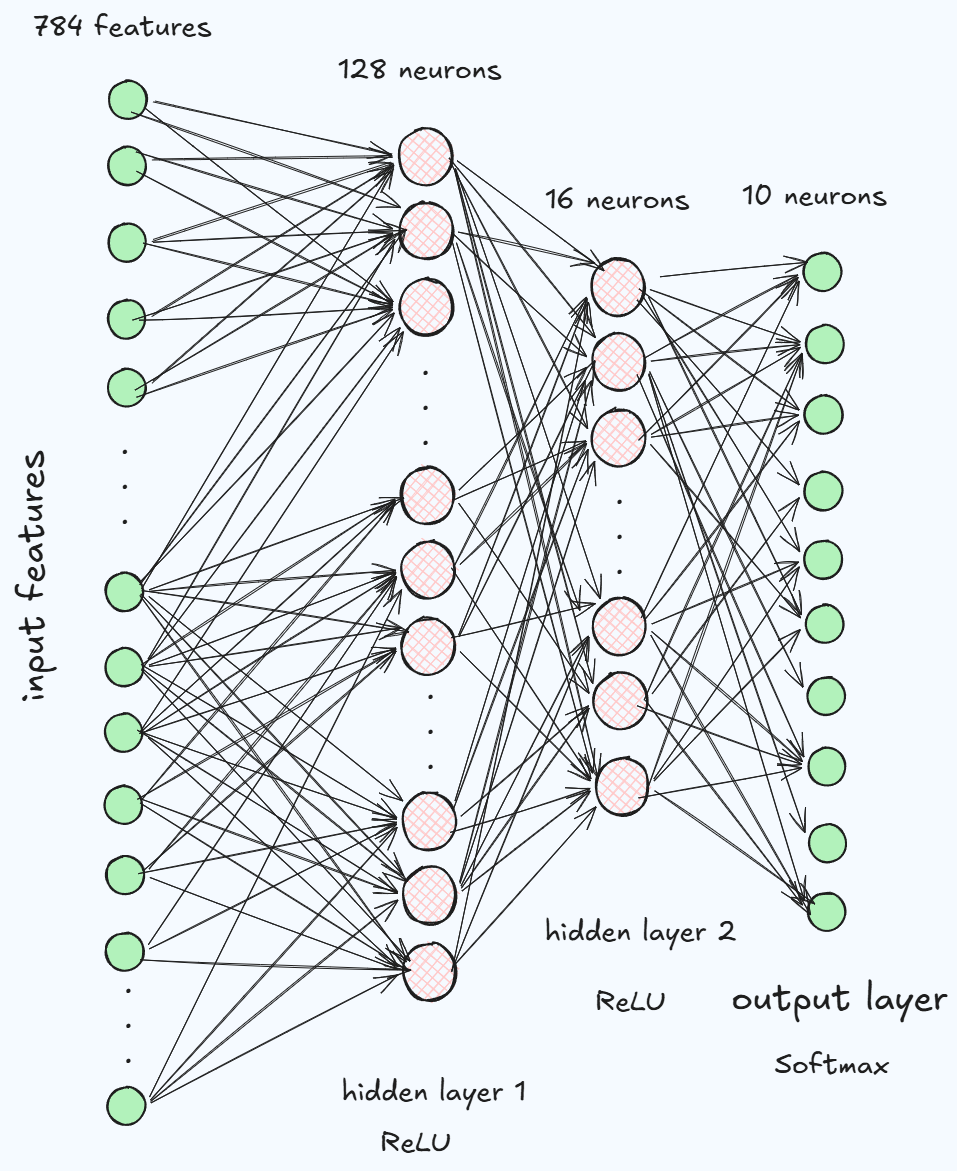

In [23]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10) # CELoss has implemented Softmax already
        )

    def forward(self, x):

        return self.model(x)


### Set epochs and learning rate

In [24]:
epochs = 100
lr = 0.1

### Set other parameters

In [25]:
# instantiate the model
model = MyNN(X_train.shape[1])
model = model.to(device) # move to gpu

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr)

### Training Loop

In [26]:
# training loop

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        # move data to gpu
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # clear grads
        optimizer.zero_grad()

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # backward pass
        loss.backward()

        # update params
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")



Epoch: 1, Loss: 2.3035253593126934
Epoch: 2, Loss: 2.3032298893928527
Epoch: 3, Loss: 2.3030459705988564
Epoch: 4, Loss: 2.302562909126282
Epoch: 5, Loss: 2.3008626632690428
Epoch: 6, Loss: 2.2874084800084433
Epoch: 7, Loss: 2.1488351446787517
Epoch: 8, Loss: 1.9181460252602895
Epoch: 9, Loss: 1.6992573640346527
Epoch: 10, Loss: 1.5606842772165934
Epoch: 11, Loss: 1.446840663433075
Epoch: 12, Loss: 1.384887450615565
Epoch: 13, Loss: 1.3310104511181513
Epoch: 14, Loss: 1.2790429348945618
Epoch: 15, Loss: 1.2288444681564967
Epoch: 16, Loss: 1.2001630288759868
Epoch: 17, Loss: 1.1600780876874923
Epoch: 18, Loss: 1.1667657767534256
Epoch: 19, Loss: 1.1328388752539953
Epoch: 20, Loss: 1.1014082849820455
Epoch: 21, Loss: 1.0833507637580235
Epoch: 22, Loss: 1.0541156821250917
Epoch: 23, Loss: 1.027288263877233
Epoch: 24, Loss: 1.0071646940112113
Epoch: 25, Loss: 0.9734870765805245
Epoch: 26, Loss: 0.9594942379991214
Epoch: 27, Loss: 0.9501716880400976
Epoch: 28, Loss: 0.9574193151990572
Epoch

### Set model to evaluation mode

In [27]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

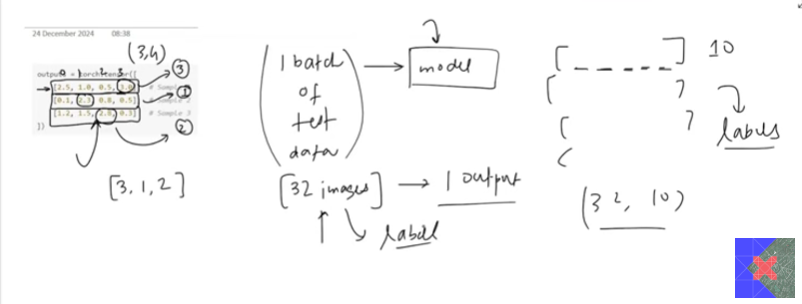

### Test Accuracy

In [28]:
# Accuracy = Number of correct predictions/Total number of prediction

total_predictions = 0
correct_predictions = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        model_predictions = model(batch_features)
        _, predicted_labels_idx = torch.max(model_predictions, dim=1) #  the index of the maximum value along dim=1 (which represents the class probabilities) is the predicted class label.
        total_predictions += batch_features.shape[0] # adds 32 (batch size)
        correct_predictions += (predicted_labels_idx == batch_labels).sum().item()

    print(correct_predictions/total_predictions)

0.7868333333333334


### Train Accuracy

In [29]:
# Accuracy = Number of correct predictions/Total number of prediction

total_predictions = 0
correct_predictions = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        model_predictions = model(batch_features)
        _, predicted_labels_idx = torch.max(model_predictions, dim=1) #  the index of the maximum value along dim=1 (which represents the class probabilities) is the predicted class label.
        total_predictions += batch_features.shape[0] # adds 32 (batch size)
        correct_predictions += (predicted_labels_idx == batch_labels).sum().item()

    print(correct_predictions/total_predictions)

0.794375
